# Fund Workstation

## Pre-Analysis Loading

#### Environment Setting

In [1]:
import pandas as pd
import plotly.graph_objects as go
from src.fofproject.fund import Fund, input_monthly_returns, subset_of_funds, compare_funds
from fofproject.batch import plot_cumulative_returns, plot_fund_correlation_heatmap
from src.fofproject.mvo import minimum_variance_analysis
from src.fofproject.load import load_saved_json, init_funds, process_pdfs_in_folder, save_changes_in_fund, merge_funds, rerun_no_perf_files, continue_running

# Names of our portfolio & benchmark indices
our_portfolio = ['TAIREN','HAO','LEXINGTON','LIM','FOREST','WT CHINA','E20','3W GLOBAL','3W CHINA','3W HEALTHCARE','TIMEFOLIO','MONOLITH','PERSEVERANCE','NEO IVY','JH BIOTECH']
our_index = ['MSCI CHINA','TOPIX','S&P 500','MSCI WORLD', 'EUREKAHEDGE']

#### Load Data via .json

In [18]:
test = load_saved_json(folder_path=r"input\forest avenue")
funds = init_funds(test)


In [3]:
port = load_saved_json(folder_path=r"input\portfolio")
port = init_funds(port)
funds = funds | port

#### Load Data via .csv

In [ ]:
# Use for manually update csv data and merge with json file 
csv_fund = input_monthly_returns(r"RETURN DATA.csv")

In [12]:
# Use for manually update csv data and merge with json file 
csv_fund = input_monthly_returns(r"input\forest avenue\returns.csv")

#### GPT Input Factsheet

##### Parse Everything

In [ ]:
# Do not open the pdf while running, or the renaming process will encounter error
gpt_fund = process_pdfs_in_folder(folder_path=r"input\Singapore",save=True)
gpt_fund = init_funds(gpt_fund)

Processing: input\Singapore\426c28508be048d0bdcadbe65c9550df.pdf
Processing: input\Singapore\9dc1d334a43c436abd5c2283e6d639c0.pdf
Processing: input\Singapore\bf397aa7de491df4983ec2c9ae37e437.pdf


##### Continue Running Unparsed

In [2]:
gpt_fund_2 = continue_running(folder_path=r"input\less_compelling",save=True)
gpt_fund_2 = init_funds(gpt_fund_2)

Processing: input\less_compelling\ENGADINE_EU_EquityLS_less than 1 Sharpe.pdf
Processing: input\less_compelling\FINEPOINT_ASIA_Eventdriven_5% rtn.pdf
Processing: input\less_compelling\FORT_NA_Event driven_7.8%rtn.pdf
Processing: input\less_compelling\G2_US_TMT specialist_less than 1 sharpe.pdf
Processing: input\less_compelling\GCM Grosvenor_US_EquityLS_7% rtn.pdf
Processing: input\less_compelling\GMO_US_EquityLS_18%vol.pdf
Processing: input\less_compelling\GOLDENTREE_NY_Credit_9.7% rtn.pdf
Processing: input\less_compelling\GREENHOUSE_US_EquityLS_less than 1 Sharpe.pdf
Processing: input\less_compelling\GREENVALE_Global_Market Neutral_less than 1 Sharpe.pdf
Processing: input\less_compelling\HIGHBRIDGE_Global_Multi-strat_8% rtn 5% vol.pdf
Processing: input\less_compelling\HIGHGROUND_Global_EquityLS_less than 1 sharpe.pdf
Processing: input\less_compelling\ICW_Global_Long only_9% rtn.pdf
Processing: input\less_compelling\ISHANA_China&India_Fundamental_19% vol.pdf
Processing: input\less_comp

In [ ]:
gpt_fund = gpt_fund_2 | gpt_fund

##### Re-Run No Performance Funds

In [ ]:
# Target the files with "No Performance Found", and re-run the analysis again
rerun_no_perf_files(folder_path=r"input\worth_a_look",save=True)

#### Merging Different Input

In [19]:
# Use the left hand's PERFORMANCE TABLE to update the right hand one
funds = merge_funds(csv_fund, funds)

In [ ]:
# Right-hand side has higher priority
funds = csv_fund | gpt_fund

#### Save the Changes to .json & .csv

In [ ]:
# Careful what fund you are saving to what folder
save_changes_in_fund(funds, folder_path=r"input\Singapore")

⚠️ Skipping FOREST (no performance data).
🔄 Existing CSV found. Updated with new data and saved to input\forest avenue\returns.csv


{'3W CHINA': Fund(performance_fee=0.2, management_fee=0.02, monthly_returns=162 entries),
 '3W GLOBAL': Fund(performance_fee=0.2, management_fee=0.02, monthly_returns=127 entries),
 '3W HEALTHCARE': Fund(performance_fee=0.15, management_fee=0.015, monthly_returns=55 entries),
 'E20': Fund(performance_fee=0.2, management_fee=0.015, monthly_returns=2 entries),
 'EUREKAHEDGE': Fund(performance_fee=0.2, management_fee=0.01, monthly_returns=92 entries),
 'FOREST': Fund(performance_fee=0.2, management_fee=0.0125, monthly_returns=0 entries),
 'FOREST AVENUE': Fund(performance_fee=0.2, management_fee=0.0125, monthly_returns=36 entries),
 'HAO': Fund(performance_fee=0.2, management_fee=0.02, monthly_returns=133 entries),
 'JAPAN CATALYST': Fund(performance_fee=0.1, management_fee=0.005, monthly_returns=49 entries),
 'JH BIOTECH': Fund(performance_fee=0.2, management_fee=0.015, monthly_returns=68 entries),
 'LEXINGTON': Fund(performance_fee=0.2, management_fee=0.02, monthly_returns=152 entries),

In [ ]:
print(funds['ASIAN TECHNOLOGY'].total_max_dd)

In [15]:
funds = gpt_fund

## Fund Analysis

#### Dataframe Comparison

In [5]:
df = compare_funds(funds)
do_not_display = our_index + our_portfolio
df = df[~df["Name"].isin(do_not_display)].reset_index(drop=True)
df.head(3)

,Name,Description,Location,Strategy,Sector,Managers,Contact,AUM (in Mn USD),Net Exposure,Net Return,...,Latest Date,Month Running,# Months,Cumulative Return,Annualized Return,Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Positive Months
0,APEX,"APEX is a systematic, multi-strategy hedge fun...",[global],"[systematic, multi-strat]",equity_diversified,"Jorge Fernandez Cuervo, Cameron McElroy","Jorge Fernandez Cuervo - Based in LONDON, UNIT...",4283.0,Net Exposure = 0% to 0%,True,...,2025-06-01,62.900000,63,1.452383,0.186335,0.087386,2.132319,4.723199,0.061645,0.730159
1,ARVIN,ARVIN is a hedge fund focused on equity long/s...,"[north_america, global]","[equity_ls, special_situation]","[equity_consumer, equity_industrials, equity_T...","Rohan Varavadekar, Christopher Bonanni","Rohan Varavadekar - Based in Austin, Texas, Un...",508.0,Net Exposure = 30.0% to 65.0%,True,...,2025-06-01,48.700000,49,0.686744,0.136590,0.103109,1.324715,3.031259,0.084283,0.673469
2,ASIAN ALPHA,ASIAN ALPHA is an equity long/short hedge fund...,[apac],[equity_ls],[equity_diversified],"Andrew Alexander, Raymond Chan, Patrick Cheung...","Andrew Alexander - Based in Hong Kong, try rea...",72.0,Net Exposure = -10.0% to 10.0%,True,...,2025-06-01,33.466667,34,0.522823,0.160017,0.056688,2.822794,10.099125,0.023961,0.794118


In [ ]:
# Column List = ["Name", "Description", "Location", "Strategy", "Sector", "Managers", "Contact", "AUM (in Mn USD)", 
#                     "Net Exposure", "Net Return", "Mgmt Fee", "Perf Fee", "Inception Date", "Latest Date", "Month Running",
#                     "# Months", "Cumulative Return", "Annualized Return", "Volatility", "Sharpe Ratio", 
#                     "Sortino Ratio", "Max Drawdown", "Positive Months"]


In [6]:
# sort by what we think important   
df = df.sort_values(by=["Sharpe Ratio", "Annualized Return"], ascending=[False, False])
# mask and filtered only the wanted funds
mask = (df["AUM (in Mn USD)"] > 100) & (df["Month Running"] > 12) & (df["Annualized Return"] > 0.14)
df['Worth a Look'] = mask
# Display only the following columns
display_df = df[["Worth a Look","Name", "Sharpe Ratio", "Annualized Return", "AUM (in Mn USD)", "Month Running","Description","Max Drawdown" ]]
display_df


,Worth a Look,Name,Sharpe Ratio,Annualized Return,AUM (in Mn USD),Month Running,Description,Max Drawdown
2,False,ASIAN ALPHA,2.822794,0.160017,72.0,33.466667,ASIAN ALPHA is an equity long/short hedge fund...,0.023961
29,True,SELIGMAN HEALTHCARE,2.454964,0.203775,132.8,23.366667,The Seligman Healthcare Spectrum Strategy is a...,0.034927
17,True,MULTI-ALPHA,2.285885,0.171239,1041.2,114.633333,MULTI-ALPHA OPPORTUNITY is a global macro mult...,0.053596
6,False,CENTIVA,2.239032,0.066554,2840.0,100.466667,"CENTIVA is a diversified, absolute return orie...",0.027108
12,False,HELIUM,2.227511,0.148626,43.0,19.266667,HELIUM GLOBAL EVENT DRIVEN FUND is an event dr...,0.039600
8,False,DIADEMA,2.177811,0.074286,68.0,11.166667,DIADEMA is an equity long/short fund focused o...,0.007000
5,False,CARTENNA CAPITAL,2.159765,0.114787,147.7,62.900000,Cartenna Capital is a long/short equity hedge ...,0.040000
14,False,KAPITALO,2.142192,0.139036,3260.0,86.266667,KAPITALO K10 is a global macro and commodities...,0.037252
0,True,APEX,2.132319,0.186335,4283.0,62.900000,"APEX is a systematic, multi-strategy hedge fun...",0.061645
7,False,CFM CUMULUS,1.970277,0.129916,637.4,17.233333,CFM Cumulus is a multi-strategy absolute retur...,0.025634


#### Save it to CSV

In [ ]:
# Select the column you want to save
output_df = df[["Worth a Look","Name", "Sharpe Ratio", "Annualized Return", "AUM (in Mn USD)", "Month Running","Max Drawdown" ,"Net Exposure","Strategy", "Sector","Contact","Description", "Mgmt Fee", "Perf Fee"]]
output_df.to_csv("output/funds_comparison.csv", index=False)

#### Save it to a list

In [11]:
exclude_list = our_index + our_portfolio
df = df[~df["Name"].isin(exclude_list)].reset_index(drop=True)
worth_looking = df.loc[df["Worth a Look"], "Name"].tolist()
print(worth_looking)

['SELIGMAN HEALTHCARE', 'MULTI-ALPHA', 'APEX', 'HIDDENITE', 'CALIGAN', 'RIVERMONT', 'SOLEUS CAPITAL', 'WINDWARD', 'ENGINE CAPITAL', 'RUBRIC CAPITAL', 'THINK INVESTMENTS', 'WOLF HILL', 'WHG GLOBAL', 'PROEM', 'RTW']


#### Compare Performance Table

In [ ]:
funds['RDGFF'].export_monthly_table(benchmark_fund = funds['MSCI CHINA'], benchmark_name = "MSCI\nChina" ,language = "en", inception_column = True)

#### Plot Cumulative Return

In [22]:

funds_to_be_plot = subset_of_funds(funds, ['FOREST AVENUE','S&P 500','EUREKAHEDGE'])
start_month = "2015-12"
end_month = "2025-7"

plot = plot_cumulative_returns(
    funds=funds_to_be_plot,
    title="",
    start_month=start_month,
    end_month=end_month,
    style="excel",
    language="en",
    blur=False,
    aspect_lock=True,
    custom_ticks=False,
    save=False,
    toggle=False
    )


#### Correlation Heat Map

In [22]:
# Correlation heatmap
list_to_plot = our_portfolio + ['JAPAN CATALYST']
print(list_to_plot)
funds_to_be_plot = subset_of_funds(funds, list_to_plot)
start_month = "2019-12"
end_month = "2025-7"

fig, corr_df, overlap_df = plot_fund_correlation_heatmap(funds_to_be_plot, method="pearson", min_overlap=12)

['TAIREN', 'HAO', 'LEXINGTON', 'LIM', 'FOREST', 'WT CHINA', 'E20', '3W GLOBAL', '3W CHINA', '3W HEALTHCARE', 'TIMEFOLIO', 'MONOLITH', 'PERSEVERANCE', 'NEO IVY', 'JH BIOTECH', 'JAPAN CATALYST']


#### Efficient Frontier Analysis

In [23]:
minimum_variance_analysis(funds)

ValueError: Not enough overlapping months across selected funds: 1 < 12.

#### Summary of a Fund

FOREST AVENUE is a global equity long/short fund with a flexible mandate to invest opportunistically across asset classes including private investments. Founded by Tarigh Yusufi, who has 19 years of experience and a strong track record of alpha generation, the fund focuses on sectors such as energy, industrials, infrastructure, utilities, and consumer. It employs a disciplined, research-driven investment process emphasizing capital protection and opportunistic short selling. The fund is rated 4 out of 5 for its differentiated approach and experienced leadership.
Net Exposure = 50.0% to 70.0%
Maya Malde - Based in Miami, FL, USA, try reachout via email 'ir@forestavecap.com' or phone ''


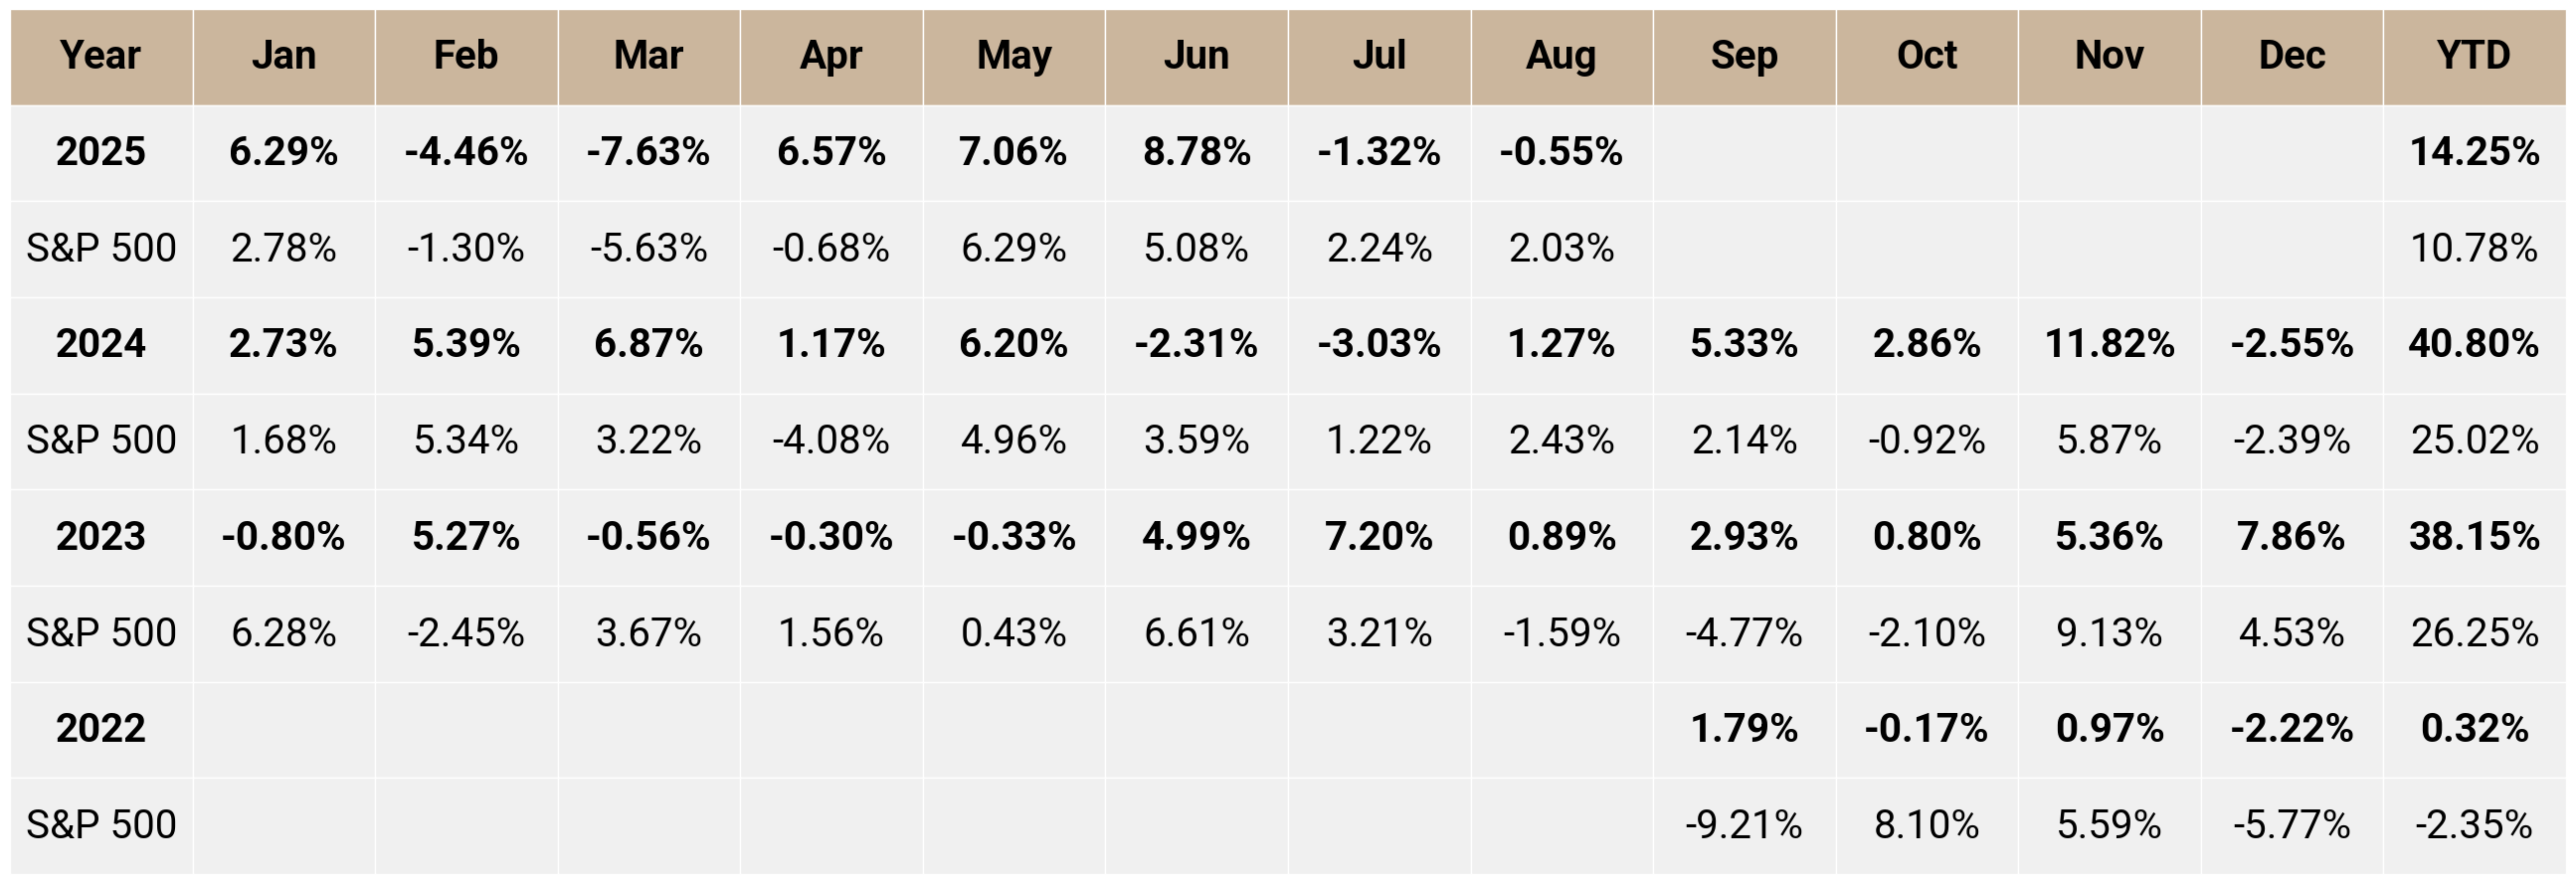

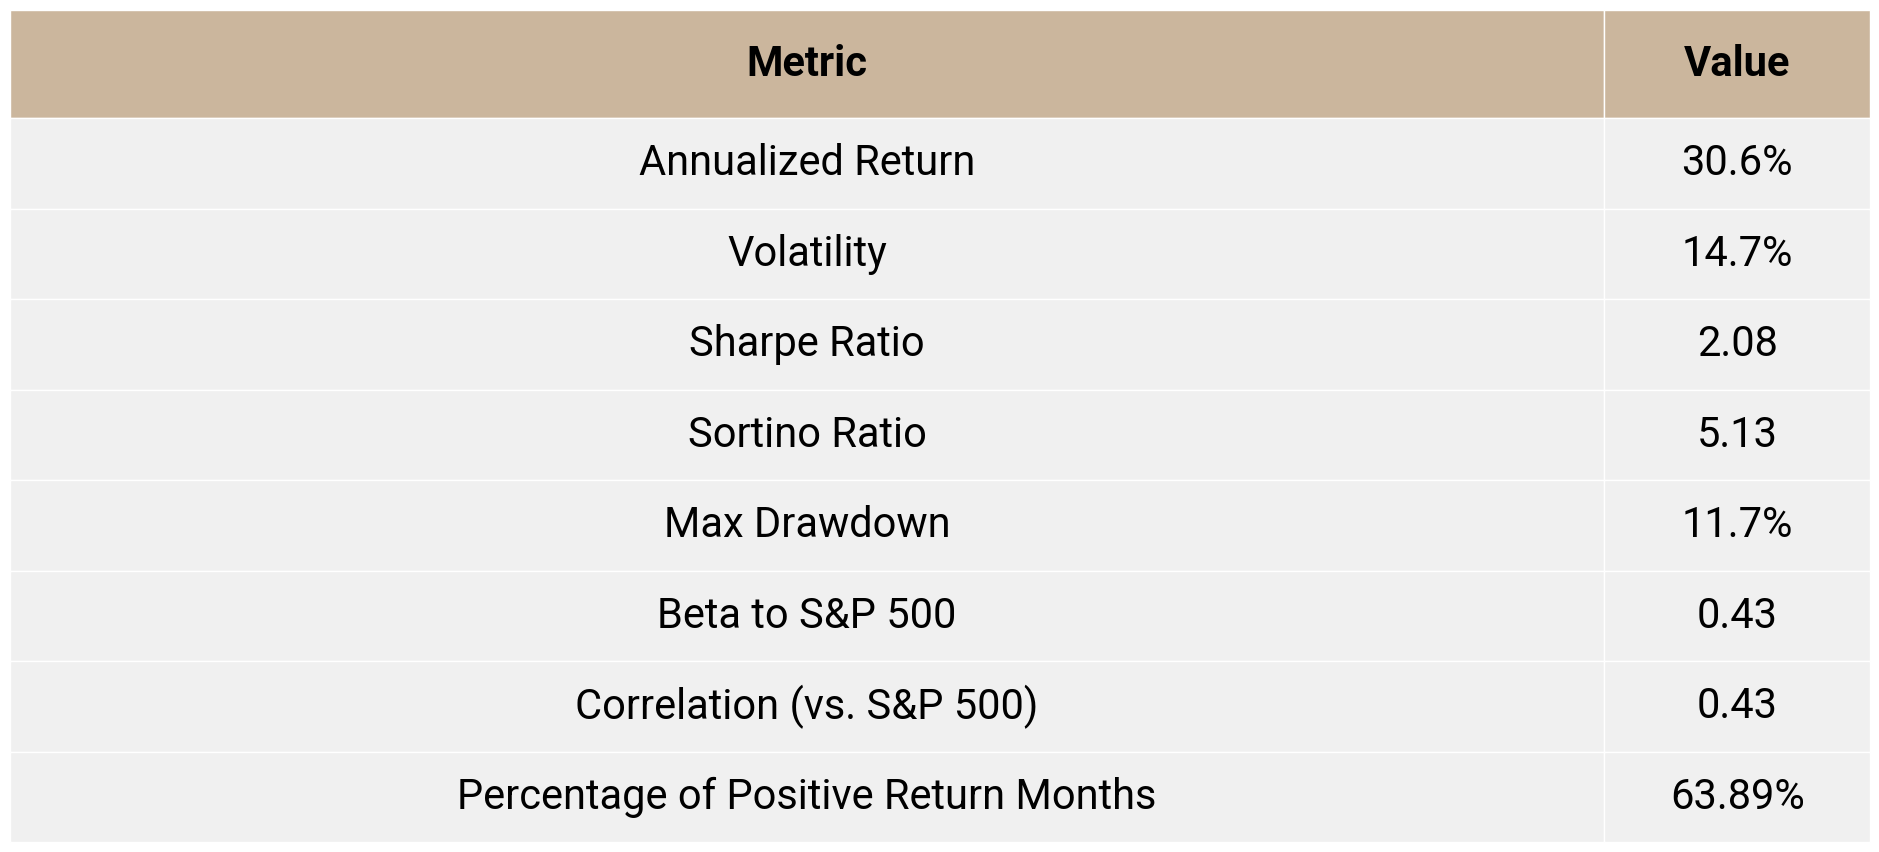

C:\Users\FOF Analyst\Desktop\fofproject\src\fofproject\fund.py:1453: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



In [23]:
funds['FOREST AVENUE'].summary_of_a_fund(benchmark_fund=funds['S&P 500'],language="en")

#### Quick Investigation

In [ ]:
the_fund_to_investigate = funds['RDGFF']
benchmark_fund = funds['MSCI CHINA']
# The List = ["cagr","vol","sharpe","sortino","mdd","beta","corr","win","best","worst","aum","skew","kurt","turnover"]

fig = the_fund_to_investigate.export_key_metrics_table(
            benchmark_fund=benchmark_fund,
            end_month=the_fund_to_investigate.latest_date,
            language="en",
            metrics=["cagr", "vol", "sharpe", "sortino", "mdd", "beta", "corr", "win"],
            horizontal=False,
        )